# **🏠 Heritage Housing — House Sales Price Study**

---

## 📋 1. Summary

## Objectives

- Answer the business requirement related to house sale prices.
- Investigate which property features are most strongly associated with `SalePrice`.
- Identify the variables that should be explored further through visual analysis.

## Inputs

- `outputs/datasets/cleaned/house_prices_cleaned.csv`

## Outputs

- Generate analysis and visualisations that can be used to support the Heritage Housing dashboard.

---

## ⚙️ 2. Set Up the Notebook

### Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/milestone-project5-heritage-housing-issues/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/milestone-project5-heritage-housing-issues'

---

## 📥 3. Load Data

Import heritage housing historical data.

In [4]:
import pandas as pd

df = pd.read_csv("outputs/datasets/cleaned/house_prices_cleaned.csv")

df.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500


---

## 🔍 4. Data Exploration

### 4.1 Pandas Profiling Report
I will inspect the dataset to understand the variable types, distributions, and relationships between property features and SalePrice.

In [5]:
from ydata_profiling import ProfileReport

pandas_report = ProfileReport(df=df, minimal=True)
pandas_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 🧹 5. Correlation Study

To calculate correlations between all variables and SalePrice, categorical variables first need to be converted into numerical form.

In [6]:
categorical_cols = df.select_dtypes(include='object').columns.to_list()

df[categorical_cols].isna().sum()

BsmtExposure    0
BsmtFinType1    0
GarageFinish    0
KitchenQual     0
dtype: int64

In [7]:
from feature_engine.encoding import OneHotEncoder

categorical_cols = df.select_dtypes(include='object').columns.to_list()

encoder = OneHotEncoder(
    variables=categorical_cols,
    drop_last=False
)

df_ohe = encoder.fit_transform(df)

print(df_ohe.shape)
df_ohe.head(3)

(1460, 41)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtUnfSF,GarageArea,GarageYrBlt,GrLivArea,LotArea,LotFrontage,...,BsmtFinType1_LwQ,GarageFinish_RFn,GarageFinish_Unf,GarageFinish_Missing,GarageFinish_Fin,GarageFinish_No Garage,KitchenQual_Gd,KitchenQual_TA,KitchenQual_Ex,KitchenQual_Fa
0,856,854.0,3.0,706,150,548,2003.0,1710,8450,65.0,...,0,1,0,0,0,0,1,0,0,0
1,1262,0.0,3.0,978,284,460,1976.0,1262,9600,80.0,...,0,1,0,0,0,0,0,1,0,0
2,920,866.0,3.0,486,434,608,2001.0,1786,11250,68.0,...,0,1,0,0,0,0,1,0,0,0


### 5.1 Spearman Correlation

Spearman correlation will be used to measure the strength and direction of the relationship between each encoded variable and `SalePrice`.

The absolute correlation values will be sorted to identify the variables most strongly associated with sale price.

In [8]:
corr_spearman = df_ohe.corr(method='spearman')['SalePrice'].sort_values(key=abs, ascending=False)[1:].head(10)
corr_spearman

OverallQual       0.809829
GrLivArea         0.731310
YearBuilt         0.652682
GarageArea        0.649379
GarageYrBlt       0.634095
TotalBsmtSF       0.602725
KitchenQual_TA   -0.581803
1stFlrSF          0.575408
YearRemodAdd      0.571159
KitchenQual_Gd    0.478583
Name: SalePrice, dtype: float64

### 5.2 Pearson Correlation

Pearson correlation will also be calculated to measure the linear relationship between each encoded variable and `SalePrice`.

The strongest relationships can then be compared with those identified by the Spearman correlation.

In [9]:
corr_pearson = df_ohe.corr(method='pearson')['SalePrice'].sort_values(key=abs, ascending=False)[1:].head(10)
corr_pearson

OverallQual       0.790982
GrLivArea         0.708624
GarageArea        0.623431
TotalBsmtSF       0.613581
1stFlrSF          0.605852
YearBuilt         0.522897
KitchenQual_TA   -0.519298
YearRemodAdd      0.507101
KitchenQual_Ex    0.504094
MasVnrArea        0.472614
Name: SalePrice, dtype: float64

In [10]:
top_n = 5
set(corr_pearson[:top_n].index.to_list() + corr_spearman[:top_n].index.to_list())

{'1stFlrSF',
 'GarageArea',
 'GarageYrBlt',
 'GrLivArea',
 'OverallQual',
 'TotalBsmtSF',
 'YearBuilt'}

- The five strongest correlations from each method were combined. 
- Since some variables appear in both lists, this resulted in **seven** unique variables being selected for further analysis.

### 5.3 Correlation Study Interpretation

Both correlation methods identify `OverallQual` and `GrLivArea` as having the strongest positive relationships with `SalePrice`.

The top five results from both methods were combined, resulting in seven variables for further study:

- `OverallQual`
- `GrLivArea`
- `GarageArea`
- `GarageYrBlt`
- `TotalBsmtSF`
- `1stFlrSF`
- `YearBuilt`

These results suggest that overall property quality, living area, garage characteristics, basement area, first-floor area and the age of the property are important factors to investigate further in relation to sale price.

In [11]:
vars_to_study = [
    'OverallQual',
    'GrLivArea',
    'GarageArea',
    'GarageYrBlt',
    'TotalBsmtSF',
    '1stFlrSF',
    'YearBuilt'
]

vars_to_study

['OverallQual',
 'GrLivArea',
 'GarageArea',
 'GarageYrBlt',
 'TotalBsmtSF',
 '1stFlrSF',
 'YearBuilt']

In [12]:
df_eda = df.filter(vars_to_study + ['SalePrice'])

df_eda.head(3)

,OverallQual,GrLivArea,GarageArea,GarageYrBlt,TotalBsmtSF,1stFlrSF,YearBuilt,SalePrice
0,7,1710,548,2003.0,856,856,2003,208500
1,6,1262,460,1976.0,1262,1262,1976,181500
2,7,1786,608,2001.0,920,920,2001,223500


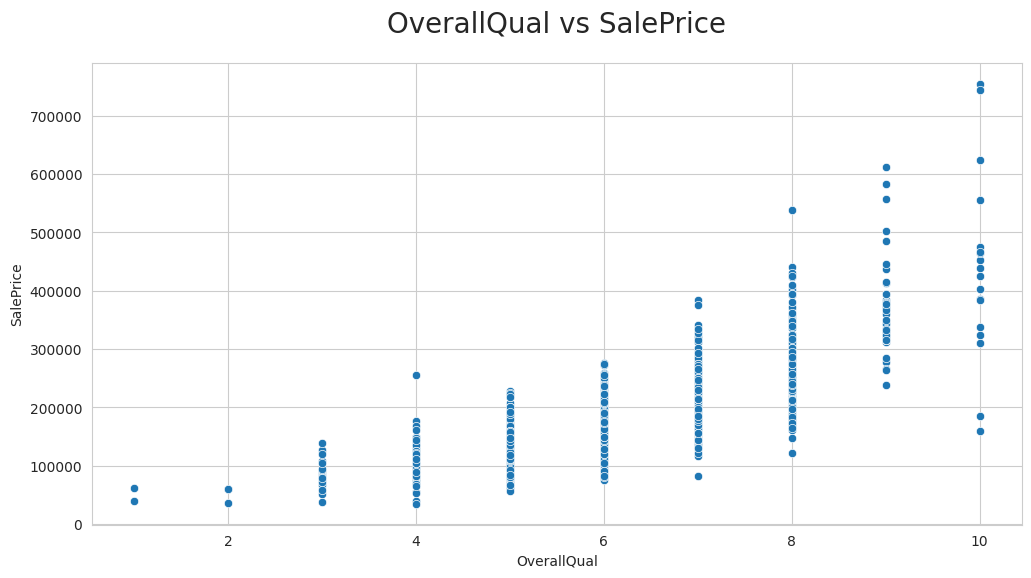

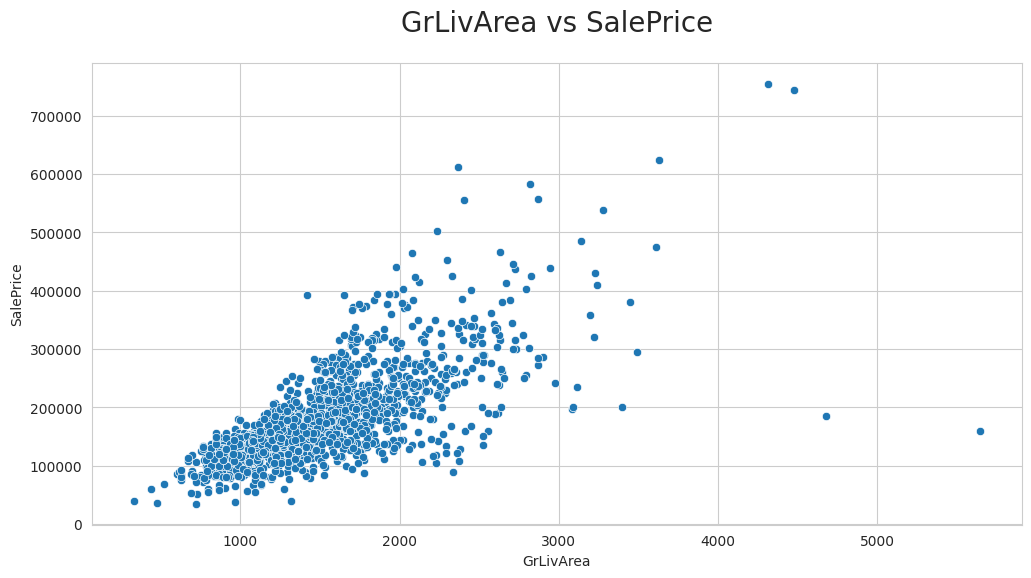

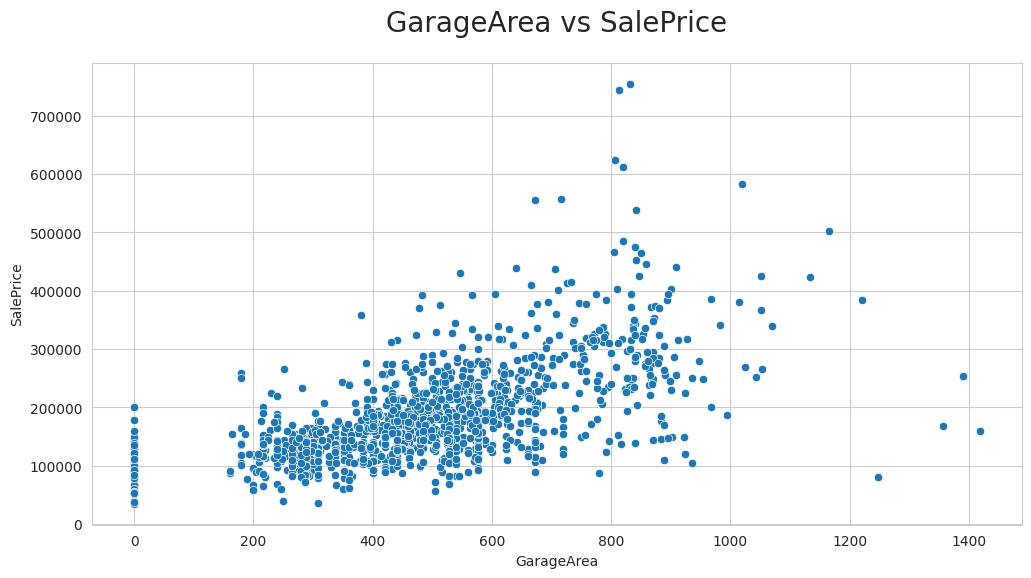

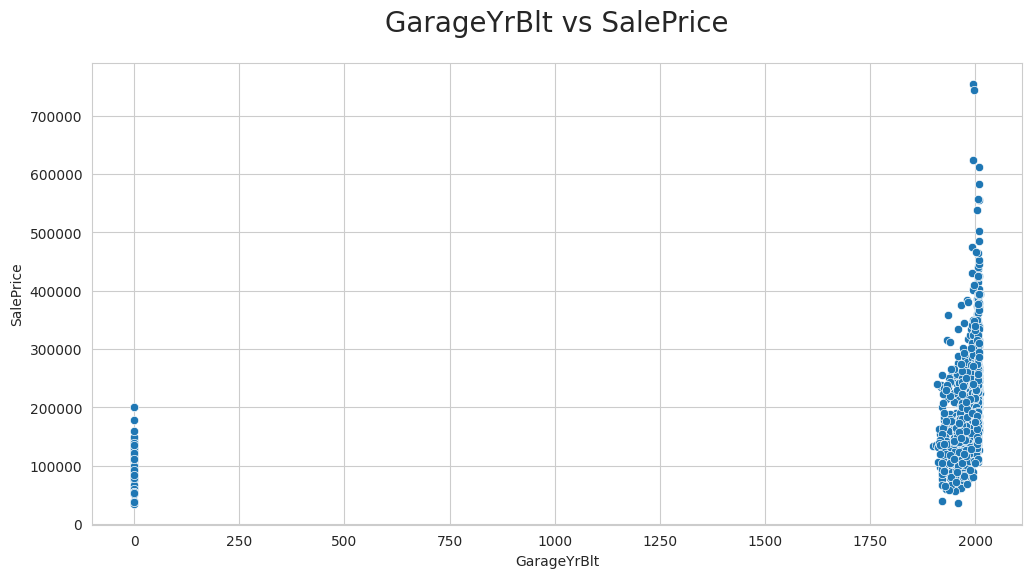

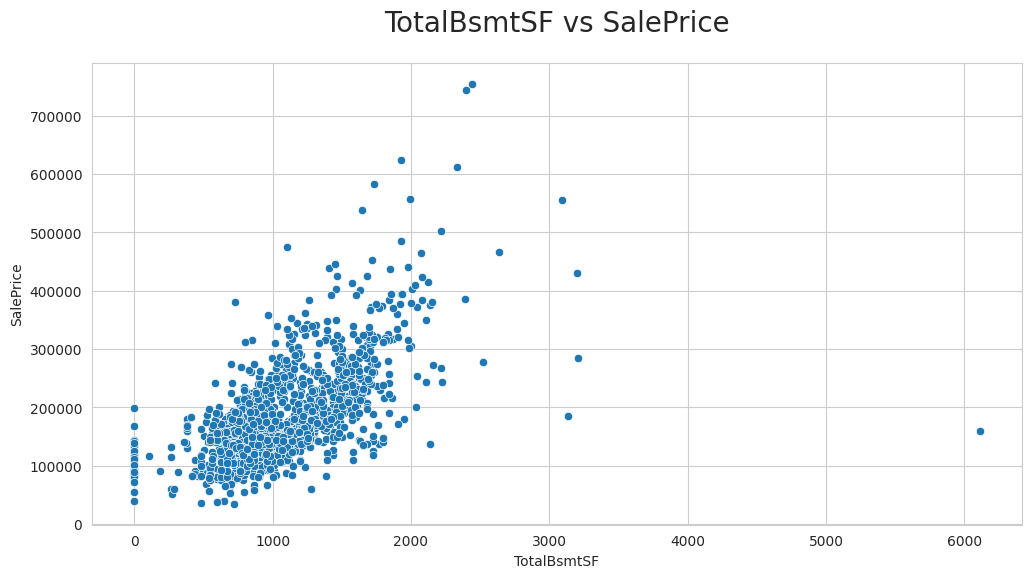

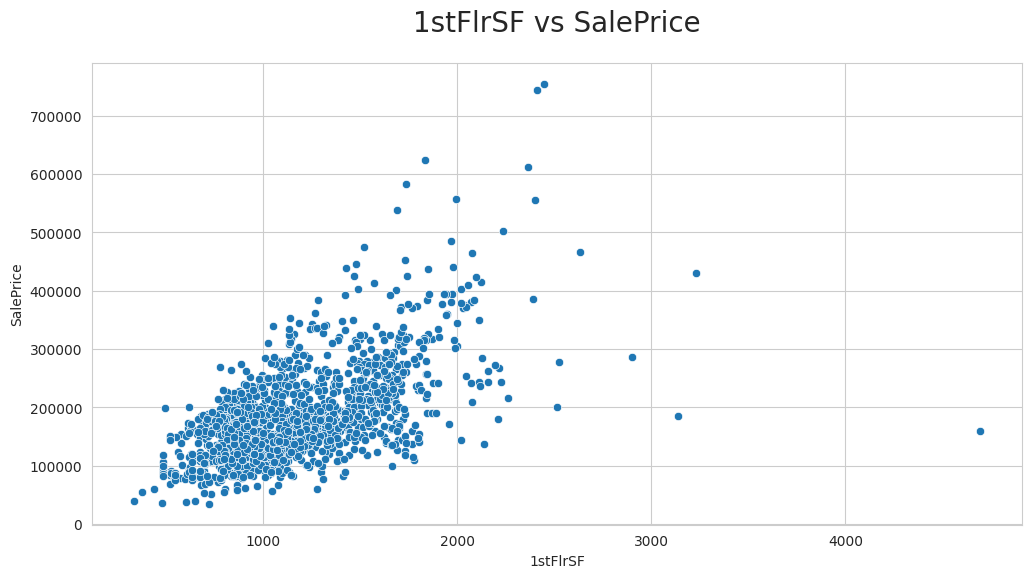

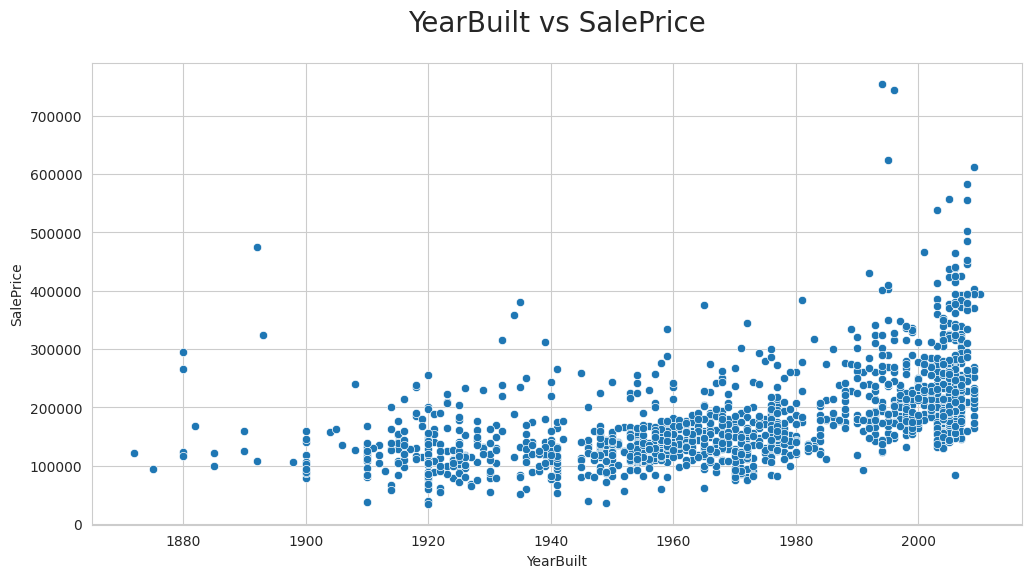

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

sns.set_style('whitegrid')


def scatter_plot_for_eda(df, col, target_var):
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x=col, y=target_var)
    plt.title(f"{col} vs {target_var}", fontsize=20, y=1.05)
    plt.show()


def variables_plots(df_eda):
    target_var = 'SalePrice'

    for col in df_eda.drop([target_var], axis=1).columns.to_list():
        scatter_plot_for_eda(df_eda, col, target_var)


variables_plots(df_eda)

### 6.1 EDA Interpretation

The scatter plots support the relationships identified in the correlation study.

- `OverallQual` shows a strong positive relationship with `SalePrice`, with higher-quality properties generally achieving higher sale prices.
- `GrLivArea` shows a clear positive relationship with `SalePrice`, although a small number of unusually large properties have relatively low sale prices.
- `GarageArea` shows a positive relationship with `SalePrice`, with larger garages generally associated with higher-priced properties.
- `GarageYrBlt` suggests that properties with more recently built garages tend to have higher sale prices. Values of zero represent properties without a garage.
- `TotalBsmtSF` shows a positive relationship with `SalePrice`, although some unusually large basement areas appear as outliers.
- `1stFlrSF` also shows a positive relationship with `SalePrice`, with larger first-floor areas generally associated with higher sale prices.
- `YearBuilt` suggests that newer properties generally achieve higher sale prices.

Overall, the visual analysis supports the correlation study and indicates that property quality, living space, garage characteristics, basement and first-floor area, and property age are associated with house sale price.

---

## ✅ 7. Conclusions

The Sale Price Study identified the property attributes most strongly associated with `SalePrice`.

- `OverallQual` and `GrLivArea` showed the strongest relationships with `SalePrice` across both Pearson and Spearman correlation methods.
- `GarageArea`, `GarageYrBlt`, `TotalBsmtSF`, `1stFlrSF`, and `YearBuilt` were also identified as important variables.
- The visual analysis supports the correlation results, showing that higher property quality, larger living areas and newer properties are generally associated with higher sale prices.
- A small number of unusual observations and outliers were visible in some variables, but these were retained for further analysis.
- The findings answer the first business requirement by identifying and visualising the house attributes most strongly associated with sale price.
- These variables can be considered further during the feature engineering and machine learning stages.